In [1]:
import sys 
sys.path.append('/Users/clairewilliams/opt/anaconda3/lib/python3.9/site-packages')
sys.path.append('../model-timescales/src')
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from timescales import TimescaleEnsemble
from timescales.data import build_bulk_energy_grid
from astropy.cosmology import FlatLambdaCDM
from timescales.analysis.modelv2 import create_dynamical_model_integral

cosmo = FlatLambdaCDM(71,0.27,Ob0=0.044, Tcmb0=2.726 *u.K)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 15

In [52]:
grid_size = 15
cutoff_density=1e6*u.Msun/(u.pc**3)

masses_array   = np.logspace(4, 9, grid_size) * u.Msun
radii_array    = np.logspace(-0.7, 2, grid_size) * u.pc
velocity_array = np.logspace(-0.7, 2.2, grid_size) * u.km/u.s

grid = build_bulk_energy_grid(masses_array, radii_array, velocity_array,
                              alpha=3/5, energy_unit=u.erg, cutoff_density=cutoff_density)


In [54]:
#set parameters
alpha = 1.25
Nsampling = 5

In [55]:
#create the timescale object

model_nobh = TimescaleEnsemble(grid, 
                    densityModel="power-law",
                    Nsampling = Nsampling,
                    timescales_kwargs={'cosmology':cosmo},
                    profile_kwargs={"alpha":alpha})

Using power-law model with properties:
alpha=1.25
Using parameters for timescale evaluation
cosmology=FlatLambdaCDM(H0=71.0 km / (Mpc s), Om0=0.27, Tcmb0=2.726 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=0.044)
No imf arguments given. Defaulting to 'salpeter defaults'.


In [56]:
out_nobh = create_dynamical_model_integral(model_nobh)

will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Using nearest neighbor for interaction type.
No Metallicity given! Using 0.1 solar
Getting disruption times for 444 systems


/Users/clairewilliams/Research/Calculations/timescale-plots/../model-timescales/src/timescales/physics/halo_environment.py:135: RuntimeWarning: invalid value encountered in divide
  normalization_offset = stfunction17/stfunction


Integrating outputs for 444 systems


/Users/clairewilliams/Research/Calculations/timescale-plots/../model-timescales/src/timescales/analysis/modelv2.py:275: RuntimeWarning: invalid value encountered in scalar power
  out['M_VMS'][sys_id]= (out['mass_accretion_rate'][sys_id].to_value(u.Msun/u.yr)/(10**(-9.13)*Z**0.74))**(1./2.1)* u.Msun


In [5]:
# BH_masses = np.logspace(2,7,11) * u.Msun
BH_masses = np.logspace(2,7,6) * u.Msun

In [6]:

models = {}
outs = {}
for i in range(len(BH_masses)):
    BHmass = BH_masses[i]
    name = "model_bh_"+str(i)
    models[name]=TimescaleEnsemble(grid, 
                        densityModel= "PowerLawBH", 
                        Nsampling = Nsampling,
                        profile_kwargs = {"alpha":alpha, 'M_bh':BH_masses[i]} )
    outs[name] = create_dynamical_model_integral(models[name])


Using PowerLawBH model with properties:
alpha=1.25
M_bh=100.0 solMass
No timescale arguments given. Defaulting to eccentricity 0, Mstar 1Msun.
No imf arguments given. Defaulting to 'salpeter defaults'.
will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
No cosmology provided. Initializing flat LCDM with H0 = 71,Om = 0.27, Ob0 = 0.044,Tcmb0=2.726 
Using nearest neighbor for interaction type.
No Metal

/Users/clairewilliams/Research/Calculations/timescale-plots/../model-timescales/src/timescales/physics/halo_environment.py:135: RuntimeWarning: invalid value encountered in divide
  normalization_offset = stfunction17/stfunction


Integrating outputs for 124 systems
Using PowerLawBH model with properties:
alpha=1.25
M_bh=1000.0 solMass
No timescale arguments given. Defaulting to eccentricity 0, Mstar 1Msun.
No imf arguments given. Defaulting to 'salpeter defaults'.
will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
No cosmology provided. Initializing flat LCDM with H0 = 71,Om = 0.27, Ob0 = 0.044,Tcmb0=2.726 
Using nearest ne

In [42]:
#prieto gonzalez

def get_vms_pgfit(masses_array, radii_array, f_b=0.1,    
    A = 716.,
    eta = 0.26,
    beta = 0.87,
    omega = 1.59,
    gamma = 0.16,
    ):
    N = masses_array/u.Msun
    Nterm = (N/(10**5))**eta 
    rterm = (radii_array/u.pc)**(-beta)
    alphaterm = (2.3)**(-omega )
    fbterm = f_b**gamma
    result = A * Nterm * rterm * alphaterm * fbterm *u.Msun
    return result.to('Msun')

# masses_array
radii=np.logspace(-2,2,100)*u.pc
masses= np.repeat(1e6 *u.Msun, len(radii))
MVMS_pg = get_vms_pgfit(masses,radii)
rho_array = masses/(4./3.*np.pi)/radii**3

MVMS_pg_upper = get_vms_pgfit(masses,radii,
    A = 716+184.,
    eta = 0.26+.13,
    beta = 0.87-0.23,
    omega = 1.59-0.39,
    gamma = 0.16+0.09,
)
MVMS_pg_lower = get_vms_pgfit(masses,radii,
    A = 716-184.,
    eta = 0.26-.13,
    beta = 0.87+0.23,
    omega = 1.59+0.39,
    gamma = 0.16-0.09,
)
#teentitans
rho_h = np.array([
    9.7,
    0.1,
    3.3,
    3.7,
    3.7,
    0.3,
    0.4,
    0.5,
    59.1,
    0.5,
    9.1,
    11.1,
    0.7,
    11.9,
    12.0,
    102.7,
    0.8,
    0.9
]) * 10**3 *u.Msun/(u.pc**3)

m_vms_max = np.array([
    334.9,
    212.8,
    213.2,
    261.8,
    282.8,
    270.1,
    276.8,
    266.0,
    397.7,
    264.2,
    270.2,
    256.1,
    266.5,
    290.0,
    268.3,
    391.9,
    268.5,
    270.8
]) *u.Msun


In [22]:
rho_array
MVMS_pg

<Quantity [1.31754593e+04, 1.21510623e+04, 1.12063126e+04, 1.03350175e+04,
           9.53146599e+03, 8.79039088e+03, 8.10693465e+03, 7.47661740e+03,
           6.89530755e+03, 6.35919477e+03, 5.86476496e+03, 5.40877725e+03,
           4.98824276e+03, 4.60040499e+03, 4.24272175e+03, 3.91284853e+03,
           3.60862306e+03, 3.32805125e+03, 3.06929400e+03, 2.83065522e+03,
           2.61057070e+03, 2.40759784e+03, 2.22040619e+03, 2.04776877e+03,
           1.88855397e+03, 1.74171818e+03, 1.60629893e+03, 1.48140857e+03,
           1.36622849e+03, 1.26000371e+03, 1.16203794e+03, 1.07168905e+03,
           9.88364819e+02, 9.11519078e+02, 8.40648124e+02, 7.75287412e+02,
           7.15008521e+02, 6.59416337e+02, 6.08146466e+02, 5.60862847e+02,
           5.17255547e+02, 4.77038732e+02, 4.39948789e+02, 4.05742603e+02,
           3.74195962e+02, 3.45102083e+02, 3.18270265e+02, 2.93524631e+02,
           2.70702979e+02, 2.49655720e+02, 2.30244893e+02, 2.12343265e+02,
           1.95833495e+02

/var/folders/lb/lrz69vl55k37335cb4q3lxnw0000gn/T/ipykernel_81941/2965126002.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize = 12)


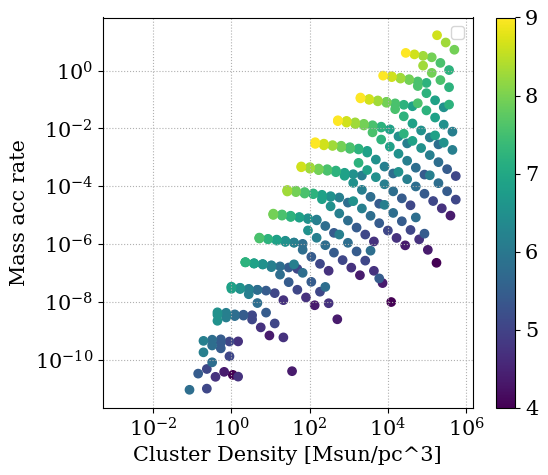

In [57]:
out = out_nobh
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(out['rho0']*(u.Msun/(u.pc**3)),out['mass_accretion_rate']*(u.Msun/u.yr),
               c=np.log10((out['mass']*u.Msun ).value))
plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"Cluster Density [Msun/pc^3]")
ax.set_ylabel(r"Mass acc rate")
ax.legend(fontsize = 12)
ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)

plt.tight_layout()
# plt.savefig("Mdot.pdf")
plt.show()

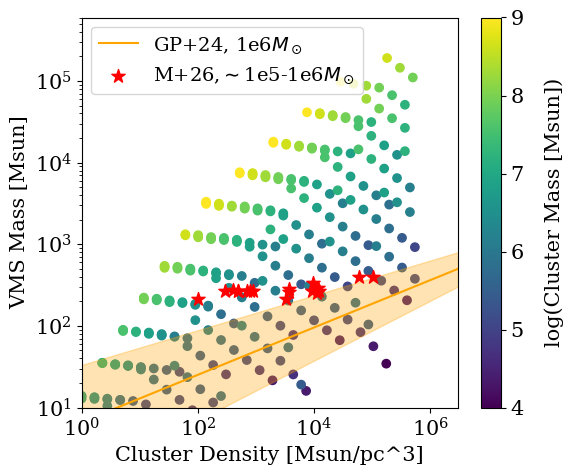

In [59]:
out = out_nobh
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(out['rho0']*(u.Msun/(u.pc**3)),out['M_VMS']*(u.Msun),
               c=np.log10((out['mass']*u.Msun ).value))
cbar = plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(rho_array, MVMS_pg, color='orange', label =r"GP+24, 1e6$M_\odot$")
ax.fill_between(rho_array.value, MVMS_pg_upper.value, y2 =MVMS_pg_lower.value,alpha = 0.3,color='orange')
# ax.plot(rho_array, MVMS_pg_upper)
# ax.plot(rho_array, MVMS_pg_lower)
plt.scatter(rho_h, m_vms_max, s =100, marker = '*', color = 'red',label =r'M+26,$\sim$1e5-1e6$M_\odot$')
ax.set_xlabel(r"Cluster Density [Msun/pc^3]")
ax.set_ylabel(r"VMS Mass [Msun]")
cbar.set_label(r'log(Cluster Mass [Msun])', rotation=90, labelpad=15)
ax.legend(loc = 'upper left', fontsize = 14)
ax.set_ylim(1e1,6e5)
ax.set_xlim(1e0,3e6)
# ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)

plt.tight_layout()
plt.savefig("rho_vms_mass.pdf",bbox_inches="tight")
plt.show()

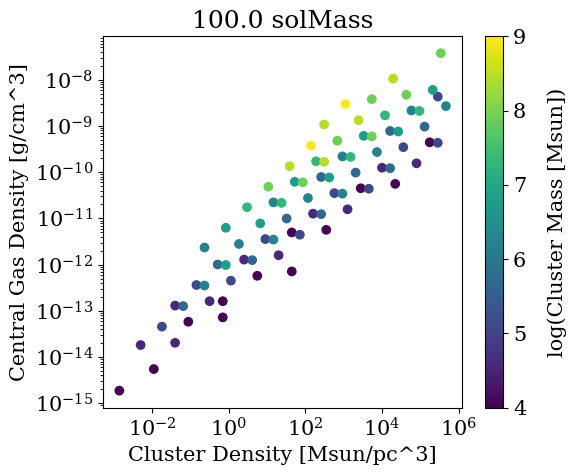

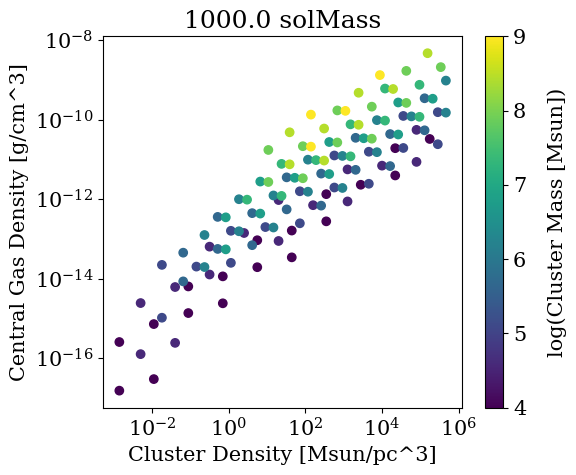

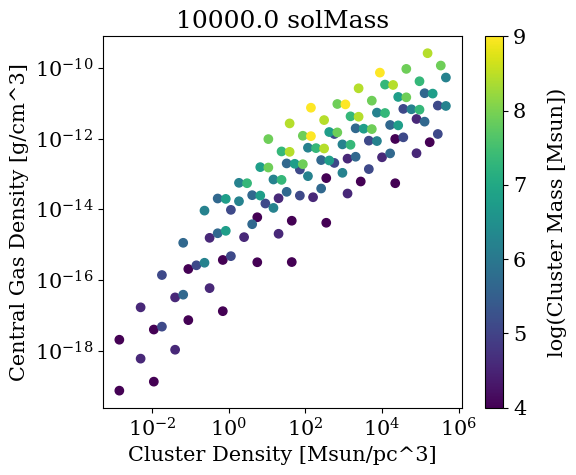

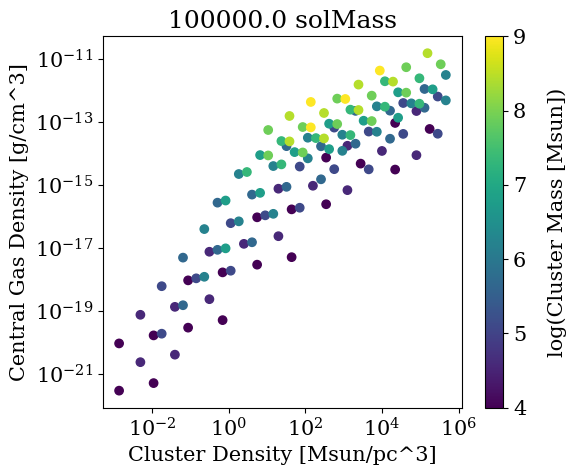

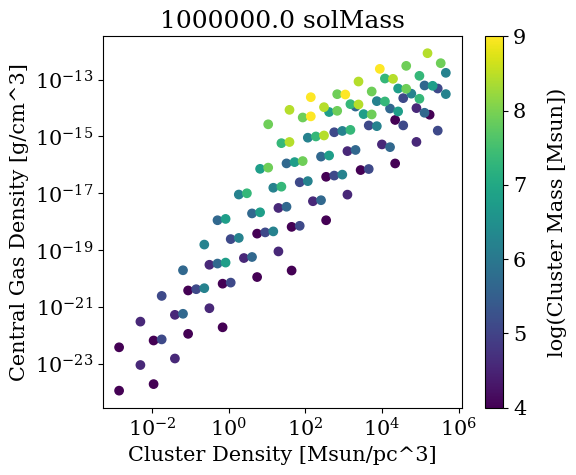

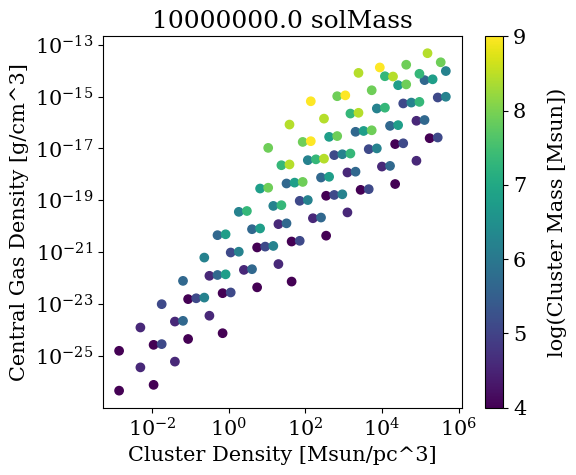

In [61]:
out = outs['model_bh_5']
for i in range(len(BH_masses)):
    BHmass = BH_masses[i]
    name = "model_bh_"+str(i)
    out = outs[name]
    fig, ax = plt.subplots(figsize=(6, 5))
    plt.scatter(out['rho0']*(u.Msun/(u.pc**3)),out['rhotot_ml']*(u.g/(u.cm**3)),
                c=np.log10((out['mass']*u.Msun ).value))
    cbar = plt.colorbar()

    #  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(r"Cluster Density [Msun/pc^3]")
    ax.set_ylabel(r"Central Gas Density [g/cm^3]")
    cbar.set_label(r'log(Cluster Mass [Msun])', rotation=90, labelpad=15)
    # ax.legend(fontsize = 12)
    # ax.grid(True, which="both", ls=":")
    # add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)
    ax.set_title(str(BHmass))
    plt.tight_layout()
    # plt.savefig("Mdot.pdf")
    plt.show()

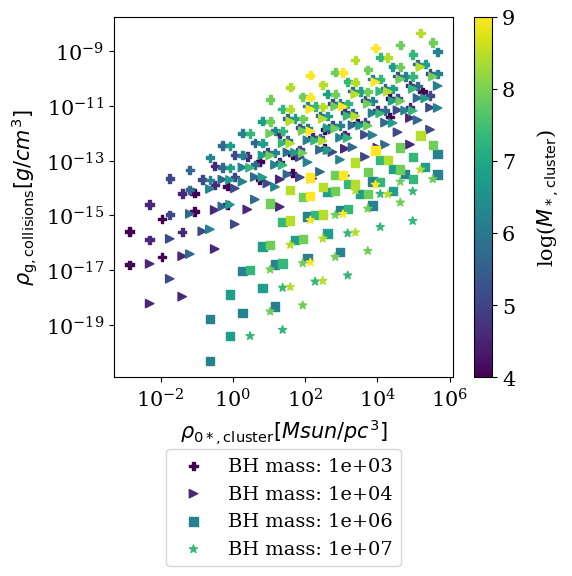

In [7]:
out = outs['model_bh_5']

fig, ax = plt.subplots(figsize=(6, 7))
markers = ['D', 'P','>','<','s','*']
vmin_val = 4
vmax_val = 9
for i in [1,2,4,5]:
    BHmass = BH_masses[i].to_value("Msun")
    name = "model_bh_"+str(i)
    out = outs[name]
    mask = np.where(((out['mass']*u.Msun ).value)>BHmass)[0]
    plt.scatter(np.array(out['rho0']*(u.Msun/(u.pc**3)))[mask],
                np.array(out['rhotot_ml']*(u.g/(u.cm**3)))[mask],
                c=np.array(np.log10((out['mass']*u.Msun ).value))[mask], marker = markers[i], 
                label=f"BH mass: {BHmass:.0e}", vmin=vmin_val, vmax=vmax_val)
cbar = plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"$\rho_{\rm 0*, cluster} [Msun/pc^3]$")
ax.set_ylabel(r"$\rho_{\rm g, collisions} [g/cm^3]$")
cbar.set_label(r'log($M_{\rm *, cluster}$)', rotation=90, labelpad=15)
ax.legend(fontsize = 14,bbox_to_anchor=(.5, -.55),loc ="lower center")
# ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)
# ax.set_title(str(BHmass))
plt.tight_layout()
plt.savefig("rhogas_rhostar_mass.pdf",bbox_inches="tight")
plt.show()

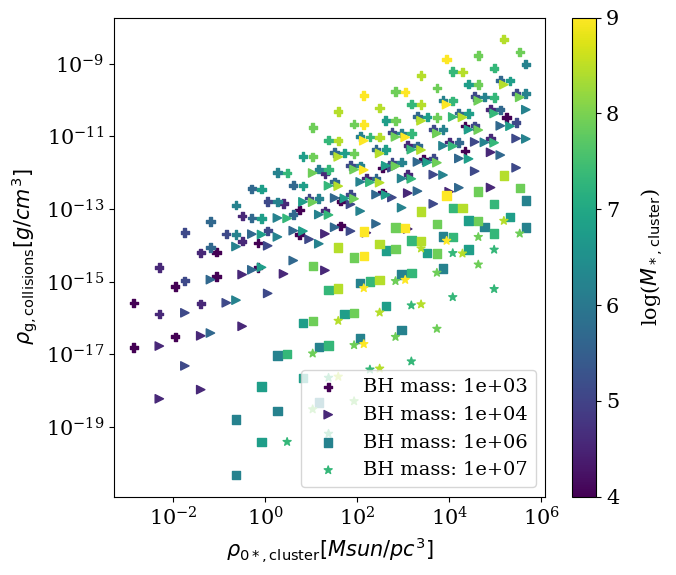

In [8]:
out = outs['model_bh_5']

fig, ax = plt.subplots(figsize=(7, 6))
markers = ['D', 'P','>','<','s','*']
vmin_val = 4
vmax_val = 9
for i in [1,2,4,5]:
    BHmass = BH_masses[i].to_value("Msun")
    name = "model_bh_"+str(i)
    out = outs[name]
    mask = np.where(((out['mass']*u.Msun ).value)>BHmass)[0]
    plt.scatter(np.array(out['rho0']*(u.Msun/(u.pc**3)))[mask],
                np.array(out['rhotot_ml']*(u.g/(u.cm**3)))[mask],
                c=np.array(np.log10((out['mass']*u.Msun ).value))[mask], marker = markers[i], 
                label=f"BH mass: {BHmass:.0e}", vmin=vmin_val, vmax=vmax_val)
cbar = plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"$\rho_{\rm 0*, cluster} [Msun/pc^3]$")
ax.set_ylabel(r"$\rho_{\rm g, collisions} [g/cm^3]$")
cbar.set_label(r'log($M_{\rm *, cluster}$)', rotation=90, labelpad=15)
ax.legend(fontsize = 14,loc="lower right")
# ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)
# ax.set_title(str(BHmass))
plt.tight_layout()
plt.savefig("rhogas_rhostar_mass.pdf",bbox_inches="tight")
plt.show()

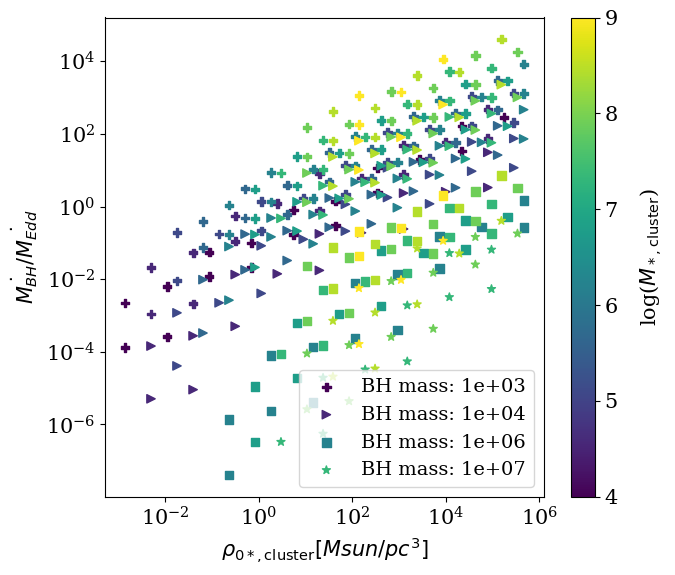

In [11]:
out = outs['model_bh_5']

fig, ax = plt.subplots(figsize=(7, 6))
markers = ['D', 'P','>','<','s','*']
vmin_val = 4
vmax_val = 9
for i in [1,2,4,5]:
    BHmass = BH_masses[i].to_value("Msun")
    name = "model_bh_"+str(i)
    out = outs[name]
    mask = np.where(((out['mass']*u.Msun ).value)>BHmass)[0]
    plt.scatter(np.array(out['rho0']*(u.Msun/(u.pc**3)))[mask],
                np.array(out['Mdot_BH']*(u.g/u.s))[mask]/np.array(out['Mdot_Edd']*(u.g/u.s))[mask],
                c=np.array(np.log10((out['mass']*u.Msun ).value))[mask], marker = markers[i], 
                label=f"BH mass: {BHmass:.0e}", vmin=vmin_val, vmax=vmax_val)
cbar = plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"$\rho_{\rm 0*, cluster} [Msun/pc^3]$")
ax.set_ylabel(r"$\dot{M_{BH}}/\dot{M_{Edd}}$")
cbar.set_label(r'log($M_{\rm *, cluster}$)', rotation=90, labelpad=15)
ax.legend(fontsize = 14,loc="lower right")
# ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)
# ax.set_title(str(BHmass))
plt.tight_layout()
plt.savefig("rhogas_Mbhdot_mass.pdf",bbox_inches="tight")
plt.show()

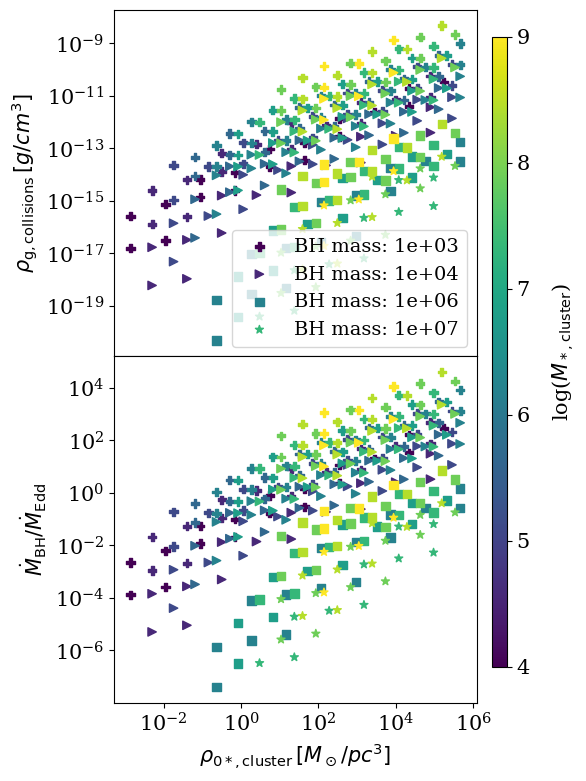

In [19]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(5, 9),
    sharex=True,
    gridspec_kw={'hspace': 0}   # <-- makes panels touch
)

markers = ['D', 'P','>','<','s','*']
vmin_val = 4
vmax_val = 9

for i in [1,2,4,5]:
    BHmass = BH_masses[i].to_value("Msun")
    name = "model_bh_"+str(i)
    out = outs[name]

    mask = np.where(((out['mass']*u.Msun ).value) > BHmass)[0]

    xvals = np.array(out['rho0']*(u.Msun/(u.pc**3)))[mask]
    y_top = np.array(out['rhotot_ml']*(u.g/(u.cm**3)))[mask]
    y_bottom = (
        np.array(out['Mdot_BH']*(u.g/u.s))[mask] /
        np.array(out['Mdot_Edd']*(u.g/u.s))[mask]
    )
    colors = np.array(np.log10((out['mass']*u.Msun ).value))[mask]

    sc = ax[0].scatter(
        xvals, y_top,
        c=colors,
        marker=markers[i],
        label=f"BH mass: {BHmass:.0e}",
        vmin=vmin_val, vmax=vmax_val
    )

    ax[1].scatter(
        xvals, y_bottom,
        c=colors,
        marker=markers[i],
        vmin=vmin_val, vmax=vmax_val
    )

# -------- axis scales --------
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')

# -------- labels --------
ax[0].set_ylabel(r"$\rho_{\rm g, collisions} \,[g/cm^3]$")
ax[1].set_ylabel(r"$\dot{M}_{\rm BH}/\dot{M}_{\rm Edd}$")
ax[1].set_xlabel(r"$\rho_{\rm 0*, cluster} \,[M_\odot/pc^3]$")

ax[0].legend(fontsize=14, loc="lower right")

# -------- manual colorbar axis (prevents overlap) --------
fig.subplots_adjust(right=0.85)   # leave space on right
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label(r'log($M_{\rm *, cluster}$)', rotation=90, labelpad=15)

plt.savefig("rhogas_rhostarv2_mass.pdf", bbox_inches="tight")
plt.show()

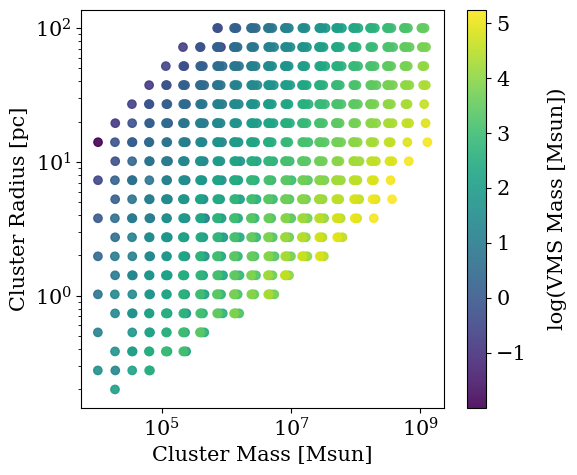

In [144]:
out = out_nobh
fig, ax = plt.subplots(figsize=(6, 5))
vratio = np.array([-out['potential'][i]/out['kinetic'][i] for i in range(len(out['potential']))])

x = np.array([out['mass'][i].value+(out['mass'][i].value *0.02 * vratio[i]) for i in range(len(vratio))]) * u.Msun

plt.scatter(x,out['radius']*(u.pc),
               c=np.log10((out['M_VMS']*(u.Msun)).value),alpha=0.9)
cbar = plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r"Cluster Radius [pc]")
ax.set_xlabel(r"Cluster Mass [Msun]")
cbar.set_label(r'log(VMS Mass [Msun])', rotation=90, labelpad=15)
# ax.legend(fontsize = 12)
# ax.set_ylim(1e1,5e5)
# ax.set_xlim(1e1,5e5)
# ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)

plt.tight_layout()
plt.savefig("mass_radius_vms.pdf",bbox_inches="tight")
plt.show()